In [1]:
import os, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer
from sklearn.linear_model import RidgeCV, Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
WORK = '/kaggle/working'

def find(name):
    hits = glob.glob(f'/kaggle/input/**/{name}', recursive=True)
    assert len(hits) == 1, (name, hits)
    return hits[0]

BASE = os.path.dirname(find('train.csv'))
test = pd.read_csv(f'{BASE}/test.csv')
folds = pd.read_csv(find('folds.csv'))
fg = pd.read_csv(find('folds_group.csv'))
folds = folds.merge(fg[['uid', 'g120', 'g250']], on='uid', how='left')
assert folds[['g120', 'g250']].isna().sum().sum() == 0
te_uids = ['test/' + f for f in test.filename]

TF = pd.read_csv(find('text_features.csv'), index_col='uid')
TF_tr, TF_te = TF.loc[folds.uid], TF.loc[te_uids]

LS = pd.read_csv(find('llm_scores.csv')).set_index('uid')
llm_ids = pd.read_csv(find('llm_uids.csv')).uid.tolist()
assert llm_ids == LS.index.tolist(), 'llm uid order mismatch'
llm_cols = ['e', 'ent'] + [f'p{k}' for k in range(1, 6)] + [f'l{k}' for k in range(1, 6)]
LS_tr, LS_te = LS.loc[folds.uid, llm_cols], LS.loc[te_uids, llm_cols]
Lh = np.load(find('llm_hidden_last.npy'), mmap_mode='r')
llm_ix = {u: i for i, u in enumerate(llm_ids)}
rows_tr = np.array([llm_ix[u] for u in folds.uid])
rows_te = np.array([llm_ix[u] for u in te_uids])
print('llm hidden:', Lh.shape, '| llm scalar features:', len(llm_cols), '| NaN in scalars:', int(LS[llm_cols].isna().sum().sum()))

y = folds.label.values
w = folds.w_test.values
nz = (folds.is_zero == 0).values
grp = folds.dur_group.values

def rmse(a, b): return float(np.sqrt(np.mean((a - b) ** 2)))
def pear(a, b): return float(np.corrcoef(a, b)[0, 1])
def wrmse(a, b, ww): return float(np.sqrt(np.sum(ww * (a - b) ** 2) / np.sum(ww)))
def wpear(a, b, ww):
    ma, mb = np.average(a, weights=ww), np.average(b, weights=ww)
    return float(np.sum(ww * (a - ma) * (b - mb)) /
                 np.sqrt(np.sum(ww * (a - ma) ** 2) * np.sum(ww * (b - mb) ** 2)))

def report(oof):
    r = {'non_zero': (rmse(y[nz], oof[nz]), pear(y[nz], oof[nz]))}
    for g in ['dur_45s', 'dur_60s']:
        m = nz & (grp == g)
        r[g] = (rmse(y[m], oof[m]), pear(y[m], oof[m]))
    r['test_weighted'] = (wrmse(y[nz], oof[nz], w[nz]), wpear(y[nz], oof[nz], w[nz]))
    return pd.DataFrame(r, index=['RMSE', 'Pearson']).T.round(4)

def score(oof):
    r = report(oof)
    rm, pe = r.loc['test_weighted', 'RMSE'], r.loc['test_weighted', 'Pearson']
    return dict(rmse_w=rm, pear_w=pe, proxy=(rm + 1 - pe) / 2,
                pear_45=r.loc['dur_45s', 'Pearson'], pear_60=r.loc['dur_60s', 'Pearson'])

FOLD_COLS = ['g250', 'g120']
bo = pd.read_csv(find('base_oof.csv')).set_index('uid').reindex(folds.uid)
bt = pd.read_csv(find('base_test.csv')).set_index('filename').reindex(test.filename)
W, H, T1, T2 = 'wavlm_L21_ridge', 'whisper_L30_ridge', 'text_all_ridge', 'text_noconf_ridge'
R = {n: dict(oof={c: bo[f'{n}__{c}'].values for c in FOLD_COLS}, test=bt[n].values) for n in (W, H, T1, T2)}
print('integrity, WavLM g250 (expect rmse_w 0.6125, pear_w 0.7758):', {k: round(v, 4) for k, v in score(R[W]['oof']['g250']).items() if k in ('rmse_w', 'pear_w')})
print('integrity, Whisper g250 (expect rmse_w 0.5879, pear_w 0.7936):', {k: round(v, 4) for k, v in score(R[H]['oof']['g250']).items() if k in ('rmse_w', 'pear_w')})

llm hidden: (985, 29, 3584) | llm scalar features: 12 | NaN in scalars: 0
integrity, WavLM g250 (expect rmse_w 0.6125, pear_w 0.7758): {'rmse_w': np.float64(0.6125), 'pear_w': np.float64(0.7758)}
integrity, Whisper g250 (expect rmse_w 0.5879, pear_w 0.7936): {'rmse_w': np.float64(0.5879), 'pear_w': np.float64(0.7936)}


top LLM hidden layers by mean proxy (lower is better):
 layer  proxy_mean  pear_w  rmse_w  pear_45  pear_60
     9      0.4613  0.7396  0.6565   0.7128   0.7713
    18      0.4625  0.7355  0.6613   0.7053   0.7738
    19      0.4680  0.7416  0.6521   0.7145   0.7665
    20      0.4689  0.7444  0.6494   0.7188   0.7684
    14      0.4698  0.7306  0.6674   0.6934   0.7827
    13      0.4722  0.7277  0.6706   0.6968   0.7763
    27      0.4747  0.7351  0.6607   0.7180   0.7536
     8      0.4766  0.7282  0.6693   0.6964   0.7684

                model  proxy_g250  proxy_g120  rmse_w  pear_w  pear_45  pear_60  train_rmse
 llm_hidden_L9_ridge      0.4584      0.4641  0.6565  0.7396   0.7128   0.7713      0.5168
      text_llm_ridge      0.4706      0.4683  0.6682  0.7270   0.6949   0.7609      0.6155
textnoconf_llm_ridge      0.5019      0.4922  0.6990  0.6952   0.6645   0.7186      0.6684
    llm_scalar_ridge      0.5842      0.5851  0.7865  0.6180   0.6283   0.6319      0.7823


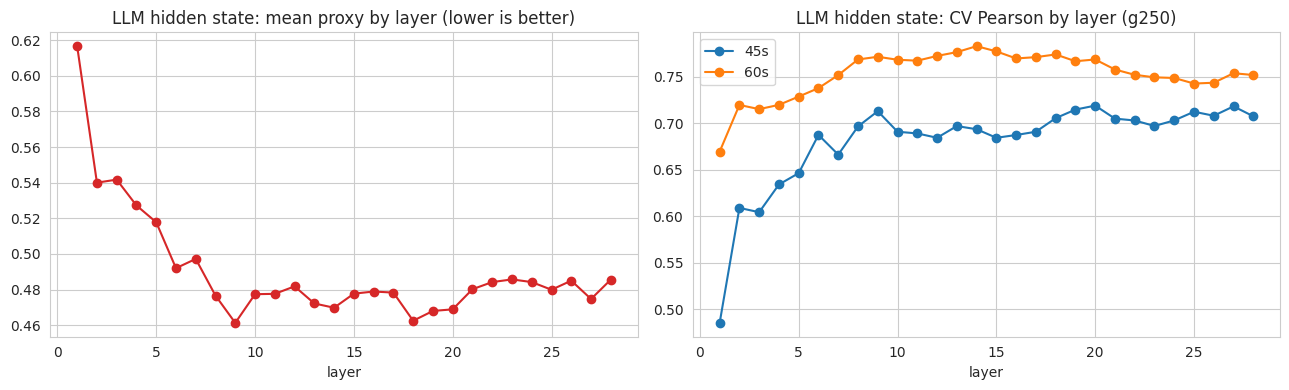

In [2]:
class Winsor(BaseEstimator, TransformerMixin):
    def __init__(self, lo=1, hi=99):
        self.lo, self.hi = lo, hi
    def fit(self, X, y=None):
        self.lo_ = np.percentile(X, self.lo, axis=0)
        self.hi_ = np.percentile(X, self.hi, axis=0)
        return self
    def transform(self, X):
        return np.clip(X, self.lo_, self.hi_)

def ridge_text():
    return make_pipeline(SimpleImputer(strategy='median'), Winsor(), StandardScaler(),
                         RidgeCV(alphas=np.logspace(-1, 4, 12)))

def ridge_hid():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(1, 6, 11)))

def cv_oof(X, col, make_model):
    oof = np.full(len(y), np.nan)
    for f in range(5):
        va = (folds[col] == f).values
        m = make_model().fit(X[(~va) & nz], y[(~va) & nz])
        oof[va & nz] = np.clip(m.predict(X[va & nz]), 1, 5)
    return oof

def run(name, X_tr, X_te, make_model):
    X_tr, X_te = np.asarray(X_tr, dtype=np.float32), np.asarray(X_te, dtype=np.float32)
    oof = {c: cv_oof(X_tr, c, make_model) for c in FOLD_COLS}
    m = make_model().fit(X_tr[nz], y[nz])
    R[name] = dict(oof=oof, test=np.clip(m.predict(X_te), 1, 5))
    s, s2 = score(oof['g250']), score(oof['g120'])
    return dict(model=name, proxy_g250=s['proxy'], proxy_g120=s2['proxy'], rmse_w=s['rmse_w'],
                pear_w=s['pear_w'], pear_45=s['pear_45'], pear_60=s['pear_60'],
                train_rmse=rmse(y[nz], np.clip(m.predict(X_tr[nz]), 1, 5)))

cols = TF.columns.tolist()
conf = [c for c in cols if c.startswith(('wp_', 'seg_logprob', 'max_no_speech'))]
noconf = [c for c in cols if c not in conf]

rows = [run('llm_scalar_ridge', LS_tr.values, LS_te.values, ridge_text),
        run('text_llm_ridge', np.hstack([TF_tr[cols].values, LS_tr.values]), np.hstack([TF_te[cols].values, LS_te.values]), ridge_text),
        run('textnoconf_llm_ridge', np.hstack([TF_tr[noconf].values, LS_tr.values]), np.hstack([TF_te[noconf].values, LS_te.values]), ridge_text)]

# last-token hidden state at layer 0 is the same token for every file, so the sweep starts at layer 1
sw = []
for L in range(1, Lh.shape[1]):
    X = np.asarray(Lh[rows_tr, L], dtype=np.float32)
    s1, s2 = score(cv_oof(X, 'g250', ridge_hid)), score(cv_oof(X, 'g120', ridge_hid))
    sw.append(dict(layer=L, proxy_mean=(s1['proxy'] + s2['proxy']) / 2, pear_w=s1['pear_w'],
                   rmse_w=s1['rmse_w'], pear_45=s1['pear_45'], pear_60=s1['pear_60']))
sw = pd.DataFrame(sw).round(4)
print('top LLM hidden layers by mean proxy (lower is better):')
print(sw.sort_values('proxy_mean').head(8).to_string(index=False))

best_L = int(sw.sort_values('proxy_mean').iloc[0].layer)
rows.append(run(f'llm_hidden_L{best_L}_ridge', np.asarray(Lh[rows_tr, best_L], dtype=np.float32),
                np.asarray(Lh[rows_te, best_L], dtype=np.float32), ridge_hid))
LH = f'llm_hidden_L{best_L}_ridge'

tab = pd.DataFrame(rows).round(4)
print('\n', tab.sort_values('proxy_g250').to_string(index=False))

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(sw.layer, sw.proxy_mean, marker='o', color='tab:red')
ax[0].set_title('LLM hidden state: mean proxy by layer (lower is better)'); ax[0].set_xlabel('layer')
ax[1].plot(sw.layer, sw.pear_45, marker='o', label='45s'); ax[1].plot(sw.layer, sw.pear_60, marker='o', label='60s')
ax[1].set_title('LLM hidden state: CV Pearson by layer (g250)'); ax[1].set_xlabel('layer'); ax[1].legend()
plt.tight_layout(); plt.show()

           name  proxy_g250  proxy_g120  rmse_w  pear_w  pear_45  pear_60  proxy_mean
  avg|W+H+TL+LH      0.3668      0.3727  0.5604  0.8267   0.7998   0.8540      0.3698
  fit|W+H+TL+LH      0.3633      0.3773  0.5495  0.8230   0.7951   0.8510      0.3703
 fit|W+H+TLn+LH      0.3638      0.3782  0.5500  0.8225   0.7951   0.8492      0.3710
 avg|W+H+TLn+LH      0.3694      0.3740  0.5645  0.8257   0.8001   0.8504      0.3717
    avg|W+H+TLn      0.3732      0.3762  0.5668  0.8204   0.7897   0.8501      0.3747
     avg|W+H+TL      0.3727      0.3778  0.5646  0.8191   0.7871   0.8518      0.3753
  fit|W+H+T1+LH      0.3688      0.3823  0.5560  0.8183   0.7883   0.8489      0.3756
     avg|W+H+LH      0.3718      0.3804  0.5632  0.8196   0.7911   0.8492      0.3761
    fit|W+H+TLn      0.3703      0.3828  0.5575  0.8169   0.7857   0.8477      0.3765
  avg|W+H+T1+LH      0.3752      0.3792  0.5702  0.8198   0.7898   0.8512      0.3772
     fit|W+H+TL      0.3720      0.3845  0.5596  0.815

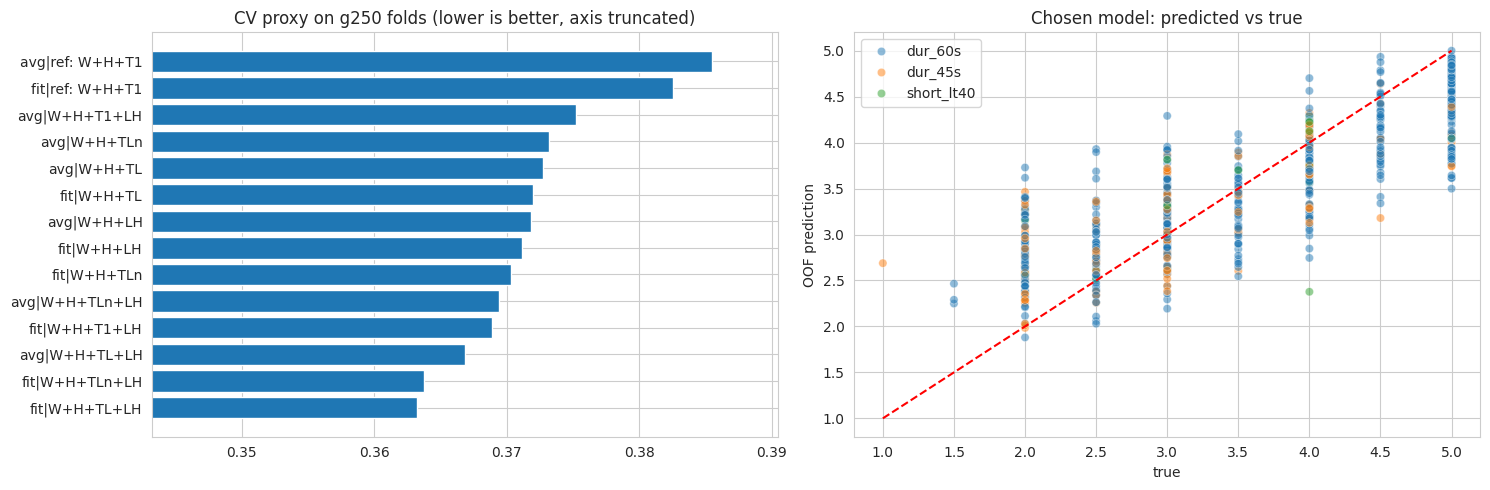

saved submission_stack_v3.csv, base2_oof.csv, base2_test.csv


In [3]:
def avg_oof(names, col): return np.mean([R[n]['oof'][col] for n in names], axis=0)
def avg_test(names): return np.mean([R[n]['test'] for n in names], axis=0)

def blend_cv(names, col, alpha=1.0):
    P = np.column_stack([R[n]['oof'][col] for n in names])
    out = np.full(len(y), np.nan)
    for f in range(5):
        va = (folds[col] == f).values
        m = Ridge(alpha=alpha, positive=True).fit(P[(~va) & nz], y[(~va) & nz])
        out[va & nz] = np.clip(m.predict(P[va & nz]), 1, 5)
    return out

def blend_fit(names, alpha=1.0, col='g250'):
    P = np.column_stack([R[n]['oof'][col] for n in names])
    T = np.column_stack([R[n]['test'] for n in names])
    m = Ridge(alpha=alpha, positive=True).fit(P[nz], y[nz])
    print('  weights', dict(zip(names, np.round(m.coef_, 3))), '| intercept', round(float(m.intercept_), 3))
    return np.clip(m.predict(T), 1, 5)

TL, TLn = 'text_llm_ridge', 'textnoconf_llm_ridge'
sets = {'ref: W+H+T1': [W, H, T1],
        'W+H+TL': [W, H, TL], 'W+H+TLn': [W, H, TLn],
        'W+H+LH': [W, H, LH], 'W+H+TL+LH': [W, H, TL, LH], 'W+H+TLn+LH': [W, H, TLn, LH],
        'W+H+T1+LH': [W, H, T1, LH]}
cands = []
for sname, names in sets.items():
    for kind in ['avg', 'fit']:
        o = {c: (avg_oof(names, c) if kind == 'avg' else blend_cv(names, c)) for c in FOLD_COLS}
        s, s2 = score(o['g250']), score(o['g120'])
        cands.append(dict(name=f'{kind}|{sname}', kind=kind, n=len(names), names=names, oof=o,
                          proxy_g250=s['proxy'], proxy_g120=s2['proxy'], rmse_w=s['rmse_w'],
                          pear_w=s['pear_w'], pear_45=s['pear_45'], pear_60=s['pear_60']))
res = pd.DataFrame([{k: v for k, v in c.items() if k not in ('names', 'oof')} for c in cands])
res['proxy_mean'] = (res.proxy_g250 + res.proxy_g120) / 2
print(res.drop(columns=['kind', 'n']).round(4).sort_values('proxy_mean').to_string(index=False))
print('\nreference (notebook 8 chosen model): proxy_g250 0.3854, proxy_g120 0.3880, mean 0.3867')

best = res.proxy_mean.min()
ok = res[res.proxy_mean <= best + 0.005].copy()
ok['is_fit'] = (ok.kind == 'fit').astype(int)
pick = ok.sort_values(['is_fit', 'n', 'proxy_mean']).iloc[0]
ch = next(c for c in cands if c['name'] == pick['name'])
print('\nbest mean proxy:', round(best, 4), '| chosen (simplest within 0.005):', ch['name'])
print(report(ch['oof']['g250']))

pred_te = avg_test(ch['names']) if ch['kind'] == 'avg' else blend_fit(ch['names'])
print('test pred summary:', pd.Series(pred_te).describe().round(3).to_dict())
prev = bt[[W, H, T1]].mean(axis=1).values
print('corr with the notebook 8 chosen model test preds:', round(pear(pred_te, prev), 4))

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
allp = res[['name', 'proxy_g250']].sort_values('proxy_g250')
ax[0].barh(allp.name, allp.proxy_g250)
ax[0].set_xlim(allp.proxy_g250.min() - 0.02, allp.proxy_g250.max() + 0.005)
ax[0].set_title('CV proxy on g250 folds (lower is better, axis truncated)')
sns.scatterplot(x=y[nz], y=ch['oof']['g250'][nz], hue=grp[nz], alpha=0.5, ax=ax[1])
ax[1].plot([1, 5], [1, 5], 'r--'); ax[1].set_xlabel('true'); ax[1].set_ylabel('OOF prediction')
ax[1].set_title('Chosen model: predicted vs true')
plt.tight_layout(); plt.show()

bp = pd.DataFrame({'uid': folds.uid})
for n in R:
    for c in FOLD_COLS:
        bp[f'{n}__{c}'] = R[n]['oof'][c]
bp.to_csv(f'{WORK}/base2_oof.csv', index=False)
pd.DataFrame({'filename': test.filename, **{n: R[n]['test'] for n in R}}).to_csv(f'{WORK}/base2_test.csv', index=False)
pd.DataFrame({'filename': test.filename, 'label': pred_te}).to_csv(f'{WORK}/submission_stack_v3.csv', index=False)
print('saved submission_stack_v3.csv, base2_oof.csv, base2_test.csv')